In [12]:
import pandas as pd
import pandas.io.sql as sqlio
import psycopg2 as ps

import warnings
warnings.filterwarnings('ignore')

In [ ]:
conn = ps.connect(
                dbname = "ANP",
                user = "postgres",
                # password = "AAAAA",
                host = "localhost",
                port="5432"
                )

In [6]:
sql = """
SELECT * FROM anp.preco_combustivel 
"""

In [7]:
df = sqlio.read_sql_query(sql, conn)

C:\Users\Lucas Lira\AppData\Local\Temp\ipykernel_3992\76855033.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = sqlio.read_sql_query(sql, conn)


In [15]:
df.head(2)

,regiao,estado,municipio,revenda,cnpj,nome_rua,numero_rua,complemento,bairro,cep,produto,data_coleta,valor_venda,unidade_medida,bandeira
0,SE,ES,COLATINA,SAO FRANCISCO DE ASSIS COMERCIO DE COMBUSTIVEI...,08.519.545/0001-10,PRACA FIDELIS FERRARI,35,None,LACE,29703-030,GASOLINA ADITIVADA,2022-07-01,7.48,R$ / litro,VIBRA ENERGIA
1,SE,ES,COLATINA,SAO FRANCISCO DE ASSIS COMERCIO DE COMBUSTIVEI...,08.519.545/0001-10,PRACA FIDELIS FERRARI,35,None,LACE,29703-030,GASOLINA,2022-07-01,7.38,R$ / litro,VIBRA ENERGIA


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378078 entries, 0 to 378077
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   regiao          378078 non-null  object 
 1   estado          378078 non-null  object 
 2   municipio       378078 non-null  object 
 3   revenda         378078 non-null  object 
 4   cnpj            378078 non-null  object 
 5   nome_rua        378078 non-null  object 
 6   numero_rua      377902 non-null  object 
 7   complemento     80547 non-null   object 
 8   bairro          377177 non-null  object 
 9   cep             378078 non-null  object 
 10  produto         378078 non-null  object 
 11  data_coleta     378078 non-null  object 
 12  valor_venda     378078 non-null  float64
 13  unidade_medida  378078 non-null  object 
 14  bandeira        378078 non-null  object 
dtypes: float64(1), object(14)
memory usage: 43.3+ MB


In [16]:
df['data_coleta'] = pd.to_datetime(df['data_coleta'])

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378078 entries, 0 to 378077
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   regiao          378078 non-null  object        
 1   estado          378078 non-null  object        
 2   municipio       378078 non-null  object        
 3   revenda         378078 non-null  object        
 4   cnpj            378078 non-null  object        
 5   nome_rua        378078 non-null  object        
 6   numero_rua      377902 non-null  object        
 7   complemento     80547 non-null   object        
 8   bairro          377177 non-null  object        
 9   cep             378078 non-null  object        
 10  produto         378078 non-null  object        
 11  data_coleta     378078 non-null  datetime64[ns]
 12  valor_venda     378078 non-null  float64       
 13  unidade_medida  378078 non-null  object        
 14  bandeira        378078 non-null  obj

In [18]:
df.isnull().sum()

regiao                 0
estado                 0
municipio              0
revenda                0
cnpj                   0
nome_rua               0
numero_rua           176
complemento       297531
bairro               901
cep                    0
produto                0
data_coleta            0
valor_venda            0
unidade_medida         0
bandeira               0
dtype: int64

In [19]:
df_anp = df[['data_coleta', 'regiao','estado','municipio','bandeira', 'produto','valor_venda',]]

In [21]:
df_anp.head(5)

,data_coleta,regiao,estado,municipio,bandeira,produto,valor_venda
0,2022-07-01,SE,ES,COLATINA,VIBRA ENERGIA,GASOLINA ADITIVADA,7.48
1,2022-07-01,SE,ES,COLATINA,VIBRA ENERGIA,GASOLINA,7.38
2,2022-07-01,SE,ES,COLATINA,VIBRA ENERGIA,DIESEL S10,7.69
3,2022-07-01,SE,ES,COLATINA,VIBRA ENERGIA,ETANOL,5.99
4,2022-07-01,SE,ES,COLATINA,VIBRA ENERGIA,GASOLINA,7.39


In [22]:
df_anp['ano'] = df_anp['data_coleta'].dt.year
df_anp['mes'] = df_anp['data_coleta'].dt.month

In [23]:
df_anp.head(5)

,data_coleta,regiao,estado,municipio,bandeira,produto,valor_venda,ano,mes
0,2022-07-01,SE,ES,COLATINA,VIBRA ENERGIA,GASOLINA ADITIVADA,7.48,2022,7
1,2022-07-01,SE,ES,COLATINA,VIBRA ENERGIA,GASOLINA,7.38,2022,7
2,2022-07-01,SE,ES,COLATINA,VIBRA ENERGIA,DIESEL S10,7.69,2022,7
3,2022-07-01,SE,ES,COLATINA,VIBRA ENERGIA,ETANOL,5.99,2022,7
4,2022-07-01,SE,ES,COLATINA,VIBRA ENERGIA,GASOLINA,7.39,2022,7


In [24]:
df_anp.describe().round(2)

,data_coleta,valor_venda,ano,mes
count,378078,378078.00,378078.0,378078.00
mean,2022-09-15 23:44:36.533413632,5.64,2022.0,9.03
min,2022-07-01 00:00:00,2.49,2022.0,7.00
25%,2022-08-01 00:00:00,4.85,2022.0,8.00
50%,2022-08-31 00:00:00,5.49,2022.0,8.00
75%,2022-11-07 00:00:00,6.65,2022.0,11.00
max,2022-12-30 00:00:00,9.65,2022.0,12.00
std,NaN,1.20,0.0,1.75


QUAIS SÃO OS TIPOS DE PRODUTOS VENDIDOS?

In [ ]:
# QUAIS SÃO OS TIPOS DE PRODUTOS VENDIDOS?
df_anp.produto.unique()

array(['GASOLINA ADITIVADA', 'GASOLINA', 'DIESEL S10', 'ETANOL', 'DIESEL',
       'GNV'], dtype=object)

QUAIS ANOS ESTÃO NA BASE?

In [ ]:
# QUAIS ANOS ESTÃO NA BASE?
df_anp.ano.unique()

array([2022], dtype=int32)

Descobrindo os valores mínimos, máximos e médios 

In [28]:
df_anp_valor = df_anp[['ano', 'produto', 'valor_venda']]

In [29]:
df_anp_valor.groupby(['ano', 'produto']).agg(['min','max','mean']).round(2)

valor_venda            
                                min   max  mean
ano  produto                                   
2022 DIESEL                    3.14  9.00  6.97
     DIESEL S10                3.59  9.65  7.08
     ETANOL                    2.49  7.89  4.21
     GASOLINA                  3.49  8.75  5.35
     GASOLINA ADITIVADA        4.09  9.28  5.52
     GNV                       3.18  7.99  5.10

In [30]:
df_anp_valor_estado = df_anp[['ano','produto','estado','valor_venda']]

In [33]:
df_anp_valor_estado.head(5)

,ano,produto,estado,valor_venda
0,2022,GASOLINA ADITIVADA,ES,7.48
1,2022,GASOLINA,ES,7.38
2,2022,DIESEL S10,ES,7.69
3,2022,ETANOL,ES,5.99
4,2022,GASOLINA,ES,7.39


In [35]:
df_anp_valor_estado.groupby(['produto','ano','estado']).agg(['min','max','mean']).round(2)

valor_venda            
                            min   max  mean
produto ano  estado                        
DIESEL  2022 AC            6.42  8.95  7.92
             AL            4.87  8.52  7.24
             AM            6.39  9.00  7.11
             AP            6.22  7.89  7.00
             BA            4.60  8.75  7.15
...                         ...   ...   ...
GNV     2022 RN            4.11  4.79  4.33
             RS            4.92  6.88  5.76
             SC            4.99  6.89  5.95
             SE            5.02  5.16  5.13
             SP            4.45  6.99  5.41

[153 rows x 3 columns]

In [36]:
df_anp_bandeira = df_anp[['ano','bandeira','produto']]

In [37]:
df_anp_bandeira.head(3)

,ano,bandeira,produto
0,2022,VIBRA ENERGIA,GASOLINA ADITIVADA
1,2022,VIBRA ENERGIA,GASOLINA
2,2022,VIBRA ENERGIA,DIESEL S10


In [41]:
df_anp_bandeira.groupby(['ano','produto']).bandeira.unique()

ano   produto           
2022  DIESEL                [IPIRANGA, BRANCA, VIBRA ENERGIA, RAIZEN, ATEM...
      DIESEL S10            [VIBRA ENERGIA, IPIRANGA, BRANCA, RAIZEN, REJA...
      ETANOL                [VIBRA ENERGIA, IPIRANGA, BRANCA, RAIZEN, REJA...
      GASOLINA              [VIBRA ENERGIA, IPIRANGA, BRANCA, RAIZEN, REJA...
      GASOLINA ADITIVADA    [VIBRA ENERGIA, IPIRANGA, BRANCA, RAIZEN, REJA...
      GNV                   [IPIRANGA, VIBRA ENERGIA, RAIZEN, REJAILE, BRA...
Name: bandeira, dtype: object

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

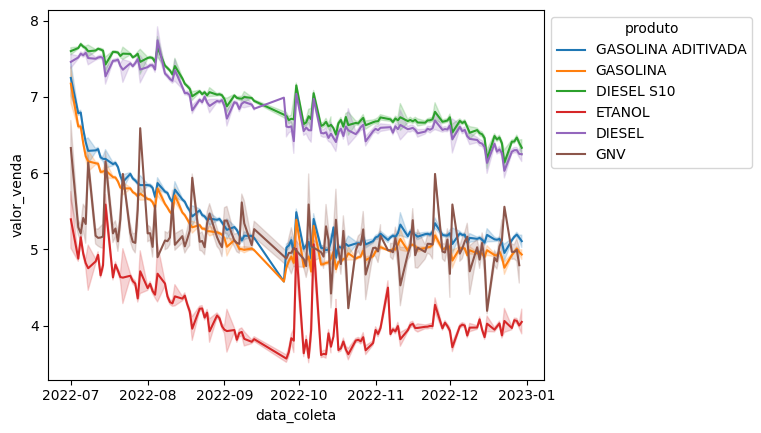

In [43]:
ax = sns.lineplot(data = df_anp, x="data_coleta", y="valor_venda", hue="produto")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))

In [44]:
# Separando o dataset
gasolina_aditivada = df_anp.loc[df['produto']=='GASOLINA ADITIVADA']
gasolina = df_anp.loc[df['produto']=='GASOLINA']
diesel_s10 = df_anp.loc[df['produto']=='DIESEL S10']
diesel = df_anp.loc[df['produto']=='DIESEL']
etanol = df_anp.loc[df['produto']=='ETANOL']
gnv = df_anp.loc[df['produto']=='GNV']


In [50]:
def plotar_boxplot_2V(titulo, labelx, labely, y, x, dataset):
    sns.set_palette('Accent')
    sns.set_style('darkgrid')
    ax = sns.boxplot(x=x, y=y, data=dataset)
    ax.figure.set_size_inches(12,6)
    ax.set_title(titulo, loc='left', fontsize = 18)
    ax.set_xlabel(labelx, fontsize = 14)
    ax.set_ylabel(labely, fontsize = 14)


def plotar_boxplot_geral(y, dataset):
    ax = sns.boxplot(y=y, data=dataset)
    ax.figure.set_size_inches(4,4)


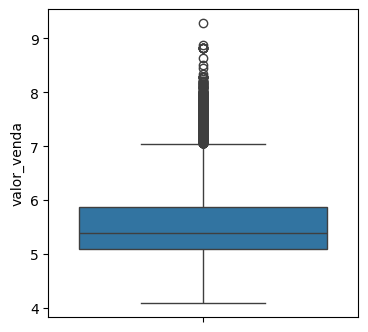

In [52]:
plotar_boxplot_geral('valor_venda',gasolina_aditivada)

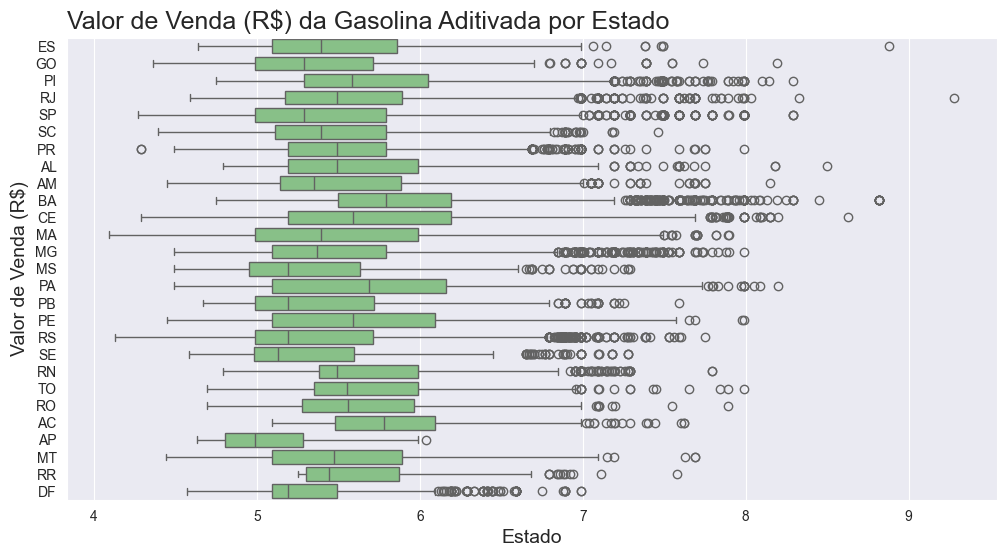

In [53]:
plotar_boxplot_2V(
    'Valor de Venda (R$) da Gasolina Aditivada por Estado',
    'Estado',
    'Valor de Venda (R$)',
    'estado',
    'valor_venda',
    gasolina_aditivada
)
